# Demo Phi-3 Mini trên Colab T4

Notebook ngắn gọn theo `KH.pdf`: host `microsoft/Phi-3-mini-4k-instruct` trên GPU T4, hỏi một câu đơn giản, sau đó chạy benchmark Spark QA. Model tải khoảng 7.64 GB; nếu Colab runtime chưa reset thì lần sau sẽ đọc lại từ cache.

In [30]:
# Chạy cell này trước khi import transformers/torch.
# Trên Colab, không cần restart runtime nếu các thư viện đã sẵn sàng.
%pip install -q "transformers>=4.40" "accelerate>=0.29" "huggingface_hub>=0.23"

## Lấy dữ liệu và mã benchmark từ GitHub

Cell này clone hoặc cập nhật repo vào `/content/a-triple-of-lms`. Benchmark sẽ lấy dataset từ `data/` và code từ `benchmarks/` trong repo này. Nếu chạy lại cell nhiều lần, notebook sẽ `git pull` thay vì clone lại.

In [31]:
from pathlib import Path
import subprocess
import sys

GITHUB_REPO_URL = "https://github.com/Hutaph/a-triple-of-lms.git"
PROJECT_DIR = Path("/content/a-triple-of-lms")

if PROJECT_DIR.exists() and (PROJECT_DIR / ".git").exists():
    subprocess.run(["git", "-C", str(PROJECT_DIR), "pull", "--ff-only"], check=True)
else:
    subprocess.run(["git", "clone", GITHUB_REPO_URL, str(PROJECT_DIR)], check=True)

DATA_PATH = PROJECT_DIR / "data" / "spark_interview_questions.json"
BENCHMARK_DIR = PROJECT_DIR / "benchmarks"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy dataset: {DATA_PATH}")
if not (BENCHMARK_DIR / "spark_qa_benchmark.py").exists():
    raise FileNotFoundError(f"Không tìm thấy benchmark script: {BENCHMARK_DIR / 'spark_qa_benchmark.py'}")

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print("Project:", PROJECT_DIR)
print("Dataset:", DATA_PATH)
print("Benchmark:", BENCHMARK_DIR / "spark_qa_benchmark.py")

Project: /content/a-triple-of-lms
Dataset: /content/a-triple-of-lms/data/spark_interview_questions.json
Benchmark: /content/a-triple-of-lms/benchmarks/spark_qa_benchmark.py


## Tải model về local runtime

Notebook không mount Google Drive. Model sẽ được tải vào local runtime của Colab, mặc định là `/content/models/phi3-mini-4k-instruct`, và cache Hugging Face nằm trong `/content/hf_cache`. Khi runtime bị reset thì các thư mục này mất, chỉ cần chạy lại cell clone GitHub và cell tải model.

In [32]:
from pathlib import Path
import os

RUNTIME_ROOT = Path("/content") if Path("/content").exists() else Path.cwd()
HF_CACHE_DIR = RUNTIME_ROOT / "hf_cache"
LOCAL_MODEL_DIR = RUNTIME_ROOT / "models" / "phi3-mini-4k-instruct"

HF_CACHE_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_MODEL_DIR.parent.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(HF_CACHE_DIR)
os.environ["HF_HUB_CACHE"] = str(HF_CACHE_DIR / "hub")
os.environ["TRANSFORMERS_CACHE"] = str(HF_CACHE_DIR / "transformers")

print("Runtime root:", RUNTIME_ROOT)
print("Hugging Face cache:", HF_CACHE_DIR)
print("Local model dir:", LOCAL_MODEL_DIR)

Runtime root: /content
Hugging Face cache: /content/hf_cache
Local model dir: /content/models/phi3-mini-4k-instruct


In [33]:
import gc
import os
import time

# Chỉ cần cho Windows/Anaconda; trên Colab dòng này không ảnh hưởng.
if os.name == "nt":
    os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
from huggingface_hub import snapshot_download
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "microsoft/Phi-3-mini-4k-instruct"

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Không có GPU. Phi-3 mini vẫn có thể chạy CPU nhưng rất chậm.")

Torch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


In [34]:
# Load tokenizer + model. Cell này có thể chạy lại sau lỗi mà không cần restart runtime.
# Quan trọng: không dùng trust_remote_code cho Phi-3 trên Colab.
# Remote code cũ của Phi-3 dễ gây lỗi RoPE: KeyError 'type' hoặc Unknown RoPE scaling type.

if "model" in globals():
    del model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

model_path = snapshot_download(
    repo_id=MODEL_ID,
    local_dir=str(LOCAL_MODEL_DIR),
    cache_dir=str(HF_CACHE_DIR / "hub"),
)
print("Model files:", model_path)

tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)

load_kwargs = {}

if torch.cuda.is_available():
    load_kwargs.update({
        "device_map": "cuda",
        "torch_dtype": torch.float16,
    })
else:
    load_kwargs.update({
        "device_map": "cpu",
        "torch_dtype": torch.float32,
    })

model = AutoModelForCausalLM.from_pretrained(model_path, local_files_only=True, **load_kwargs)
model.eval()

print("Loaded:", MODEL_ID)
print("From:", model_path)
print("Device:", next(model.parameters()).device)

Fetching 20 files:   0%|          | 0/20 [00:00<?, ?it/s]

Model files: /content/models/phi3-mini-4k-instruct


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Loaded: microsoft/Phi-3-mini-4k-instruct
From: /content/models/phi3-mini-4k-instruct
Device: cuda:0


In [35]:
def ask_phi3(question: str, max_new_tokens: int = 120) -> str:
    messages = [{"role": "user", "content": question}]
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tokenizer(prompt, return_tensors="pt")
    device = next(model.parameters()).device
    inputs = {key: value.to(device) for key, value in inputs.items()}

    start = time.perf_counter()
    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    latency = time.perf_counter() - start

    generated_ids = output_ids[0][inputs["input_ids"].shape[-1]:]
    answer = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    print(f"Latency: {latency:.1f}s")
    return answer

In [36]:
question = "Explain MapReduce in exactly 5 bullet points. Each bullet must contain no more than 15 words."

print("Question:")
print(question)
print("\nPhi-3 output:")
print(ask_phi3(question))

Question:
Explain MapReduce in exactly 5 bullet points. Each bullet must contain no more than 15 words.

Phi-3 output:
Latency: 4.2s
- MapReduce is a programming model for processing large data sets across distributed clusters.

- It involves two tasks: Map (filter and sort data) and Reduce (aggregate and summarize data).

- MapReduce simplifies data processing by abstracting the complexity of parallelization and fault-tolerance.

- It's widely used in big data applications, like search engines and data analytics.

- Hadoop is a popular framework implementing the MapReduce model.


## Benchmark Spark QA dataset

Phần này dùng `data/spark_interview_questions.json` và logic trong `benchmarks/spark_qa_benchmark.py` để chấm Phi-3. Mặc định notebook chạy full 80 câu. Nếu chỉ muốn kiểm tra nhanh, đổi `BENCHMARK_LIMIT = 5`.

In [37]:
# Kiểm tra lại repo đã được clone và đưa project vào Python path.
from pathlib import Path
import sys

if "PROJECT_DIR" not in globals():
    PROJECT_DIR = Path("/content/a-triple-of-lms")

DATA_PATH = PROJECT_DIR / "data" / "spark_interview_questions.json"
BENCHMARK_DIR = PROJECT_DIR / "benchmarks"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Không tìm thấy dataset. Hãy chạy cell clone GitHub ở phía trên trước. "
        f"Đường dẫn đang kiểm tra: {DATA_PATH}"
    )
if not (BENCHMARK_DIR / "spark_qa_benchmark.py").exists():
    raise FileNotFoundError(
        "Không tìm thấy benchmark script. Hãy chạy cell clone GitHub ở phía trên trước. "
        f"Đường dẫn đang kiểm tra: {BENCHMARK_DIR / 'spark_qa_benchmark.py'}"
    )

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print("Project:", PROJECT_DIR)
print("Dataset:", DATA_PATH)
print("Benchmark:", BENCHMARK_DIR / "spark_qa_benchmark.py")

Project: /content/a-triple-of-lms
Dataset: /content/a-triple-of-lms/data/spark_interview_questions.json
Benchmark: /content/a-triple-of-lms/benchmarks/spark_qa_benchmark.py


In [38]:
import csv
import inspect
import json
from pathlib import Path

from benchmarks import spark_qa_benchmark as benchmark

build_prompt = benchmark.build_prompt
composite_score = benchmark.composite_score
generate_answer = benchmark.generate_answer
save_visualizations = benchmark.save_visualizations
summarize = benchmark.summarize
write_csv = benchmark.write_csv


def score_answer(model_answer, reference_answer, must_have_points=None):
    if len(inspect.signature(composite_score).parameters) >= 3:
        return composite_score(model_answer, reference_answer, must_have_points)
    return composite_score(model_answer, reference_answer)


def write_human_review_template(results, path):
    if hasattr(benchmark, "write_human_review_template"):
        return benchmark.write_human_review_template(results, path)

    fields = [
        "id", "question", "category", "difficulty", "model_answer",
        "must_have_points", "auto_score", "correctness_1_5",
        "completeness_1_5", "tradeoff_1_5", "production_relevance_1_5",
        "clarity_1_5", "human_notes",
    ]
    with path.open("w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=fields)
        writer.writeheader()
        for result in results:
            writer.writerow({
                "id": result["id"],
                "question": result["question"],
                "category": result["category"],
                "difficulty": result["difficulty"],
                "model_answer": result["model_answer"],
                "must_have_points": json.dumps(result.get("must_have_points", []), ensure_ascii=False),
                "auto_score": result["score"],
                "correctness_1_5": "",
                "completeness_1_5": "",
                "tradeoff_1_5": "",
                "production_relevance_1_5": "",
                "clarity_1_5": "",
                "human_notes": "",
            })


def write_low_score_report(results, path, bottom_n=10):
    if hasattr(benchmark, "write_low_score_report"):
        return benchmark.write_low_score_report(results, path, bottom_n=bottom_n)

    lowest = sorted(results, key=lambda row: row["score"])[:bottom_n]
    lines = [
        "# Low Score Analysis",
        "",
        "Các câu dưới đây có điểm tự động thấp nhất. Nên đọc thủ công để phân biệt lỗi thật của model với hạn chế của metric token/keyword.",
        "",
    ]
    for result in lowest:
        lines.extend([
            f"## {result['id']}. {result['question']}",
            "",
            f"- Category: `{result['category']}`",
            f"- Difficulty: `{result['difficulty']}`",
            f"- Auto score: `{result['score']}`",
            f"- Token F1: `{result.get('token_f1', '')}`",
            f"- ROUGE-L: `{result.get('rouge_l', '')}`",
            f"- Keyword coverage: `{result.get('keyword_coverage', '')}`",
            "",
            "Must-have points:",
        ])
        for point in result.get("must_have_points", []):
            lines.append(f"- {point}")
        lines.extend(["", "Model answer:", "", result["model_answer"], ""])

    path.write_text("\n".join(lines) + "\n", encoding="utf-8")

BENCHMARK_LIMIT = 0  # 0 = chạy full 80 câu; đổi thành 5 nếu chỉ muốn test nhanh.
MAX_NEW_TOKENS = 220
OUTPUT_DIR = PROJECT_DIR / "benchmark_results"

dataset = json.loads(DATA_PATH.read_text(encoding="utf-8"))
if BENCHMARK_LIMIT:
    dataset = dataset[:BENCHMARK_LIMIT]

print("Benchmark questions:", len(dataset))

Benchmark questions: 80


In [39]:
results = []

for index, item in enumerate(dataset, 1):
    prompt = build_prompt(item["question"])
    model_answer, latency_s, output_tokens = generate_answer(
        tokenizer=tokenizer,
        model=model,
        prompt=prompt,
        max_new_tokens=MAX_NEW_TOKENS,
    )
    scores = score_answer(
        model_answer,
        item["reference_answer"],
        item.get("must_have_points"),
    )
    result = {
        "id": index,
        "question": item["question"],
        "category": item["category"],
        "difficulty": item["difficulty"],
        "reference_answer": item["reference_answer"],
        "must_have_points": item.get("must_have_points", []),
        "model_answer": model_answer,
        "latency_s": round(latency_s, 3),
        "output_tokens": output_tokens,
        **scores,
    }
    results.append(result)
    print(
        f"[{index:03d}/{len(dataset):03d}] "
        f"{item['difficulty']} {item['category']} "
        f"score={result['score']:.4f} latency={result['latency_s']:.1f}s"
    )

summary = summarize(results)
summary["overall"]

[001/080] medium spark_partitioning score=0.2297 latency=8.6s
[002/080] hard spark_optimization score=0.3238 latency=8.3s
[003/080] medium spark_partitioning score=0.3226 latency=8.6s
[004/080] medium spark_partitioning score=0.3407 latency=8.6s
[005/080] medium spark_join_optimization score=0.2101 latency=8.5s
[006/080] medium spark_join_optimization score=0.1085 latency=8.7s
[007/080] hard spark_join_optimization score=0.1461 latency=9.2s
[008/080] hard spark_partitioning score=0.3050 latency=9.0s
[009/080] medium spark_join_optimization score=0.2302 latency=8.5s
[010/080] medium spark_partitioning score=0.3879 latency=8.6s
[011/080] hard spark_streaming score=0.2497 latency=8.6s
[012/080] hard spark_join_optimization score=0.1553 latency=8.7s
[013/080] hard spark_join_optimization score=0.2269 latency=8.4s
[014/080] easy spark_tables score=0.2076 latency=8.7s
[015/080] hard spark_partitioning score=0.2047 latency=8.7s
[016/080] medium spark_partitioning score=0.1329 latency=8.6s
[01

{'count': 80,
 'avg_score': 0.2122,
 'avg_token_f1': 0.198,
 'avg_rouge_l': 0.1219,
 'avg_keyword_coverage': 0.3615,
 'avg_latency_s': 8.552,
 'avg_output_tokens': 217.7}

In [40]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

details_path = OUTPUT_DIR / "spark_qa_benchmark_results.json"
summary_path = OUTPUT_DIR / "spark_qa_benchmark_summary.json"
csv_path = OUTPUT_DIR / "spark_qa_benchmark_results.csv"
human_review_path = OUTPUT_DIR / "human_review_template.csv"
low_score_report_path = OUTPUT_DIR / "low_score_analysis.md"

details_path.write_text(json.dumps(results, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
summary_path.write_text(json.dumps(summary, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
write_csv(results, csv_path)
write_human_review_template(results, human_review_path)
write_low_score_report(results, low_score_report_path)
chart_paths = save_visualizations(results, summary, OUTPUT_DIR)

print("Wrote:", details_path)
print("Wrote:", summary_path)
print("Wrote:", csv_path)
print("Wrote:", human_review_path)
print("Wrote:", low_score_report_path)

Wrote: /content/a-triple-of-lms/benchmark_results/spark_qa_benchmark_results.json
Wrote: /content/a-triple-of-lms/benchmark_results/spark_qa_benchmark_summary.json
Wrote: /content/a-triple-of-lms/benchmark_results/spark_qa_benchmark_results.csv
Wrote: /content/a-triple-of-lms/benchmark_results/human_review_template.csv
Wrote: /content/a-triple-of-lms/benchmark_results/low_score_analysis.md


/content/a-triple-of-lms/benchmark_results/score_by_difficulty.png


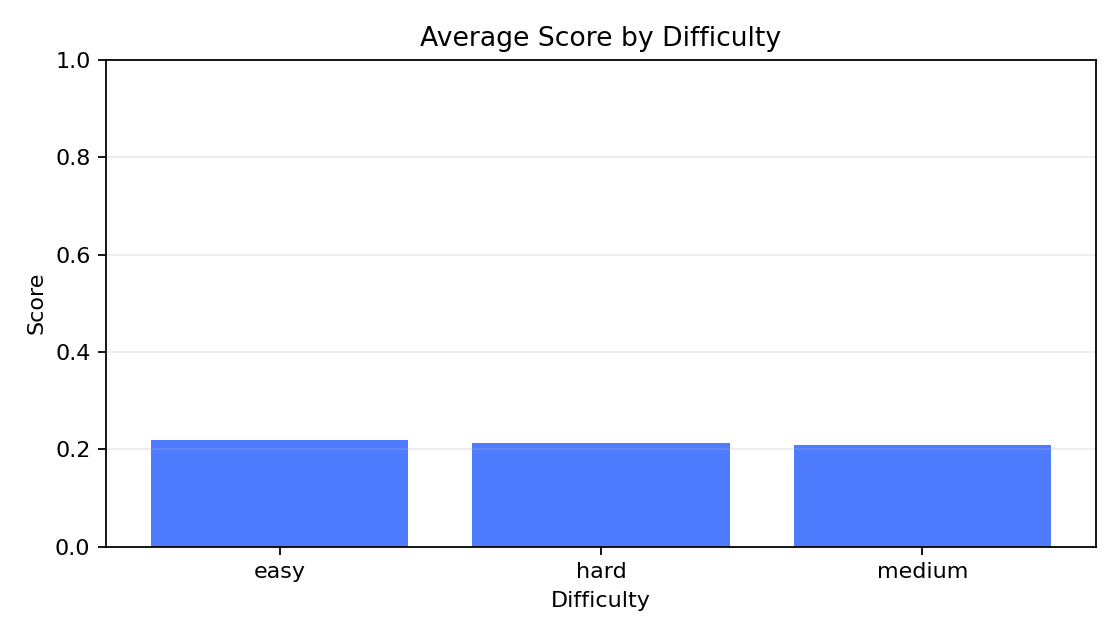

/content/a-triple-of-lms/benchmark_results/score_by_category.png


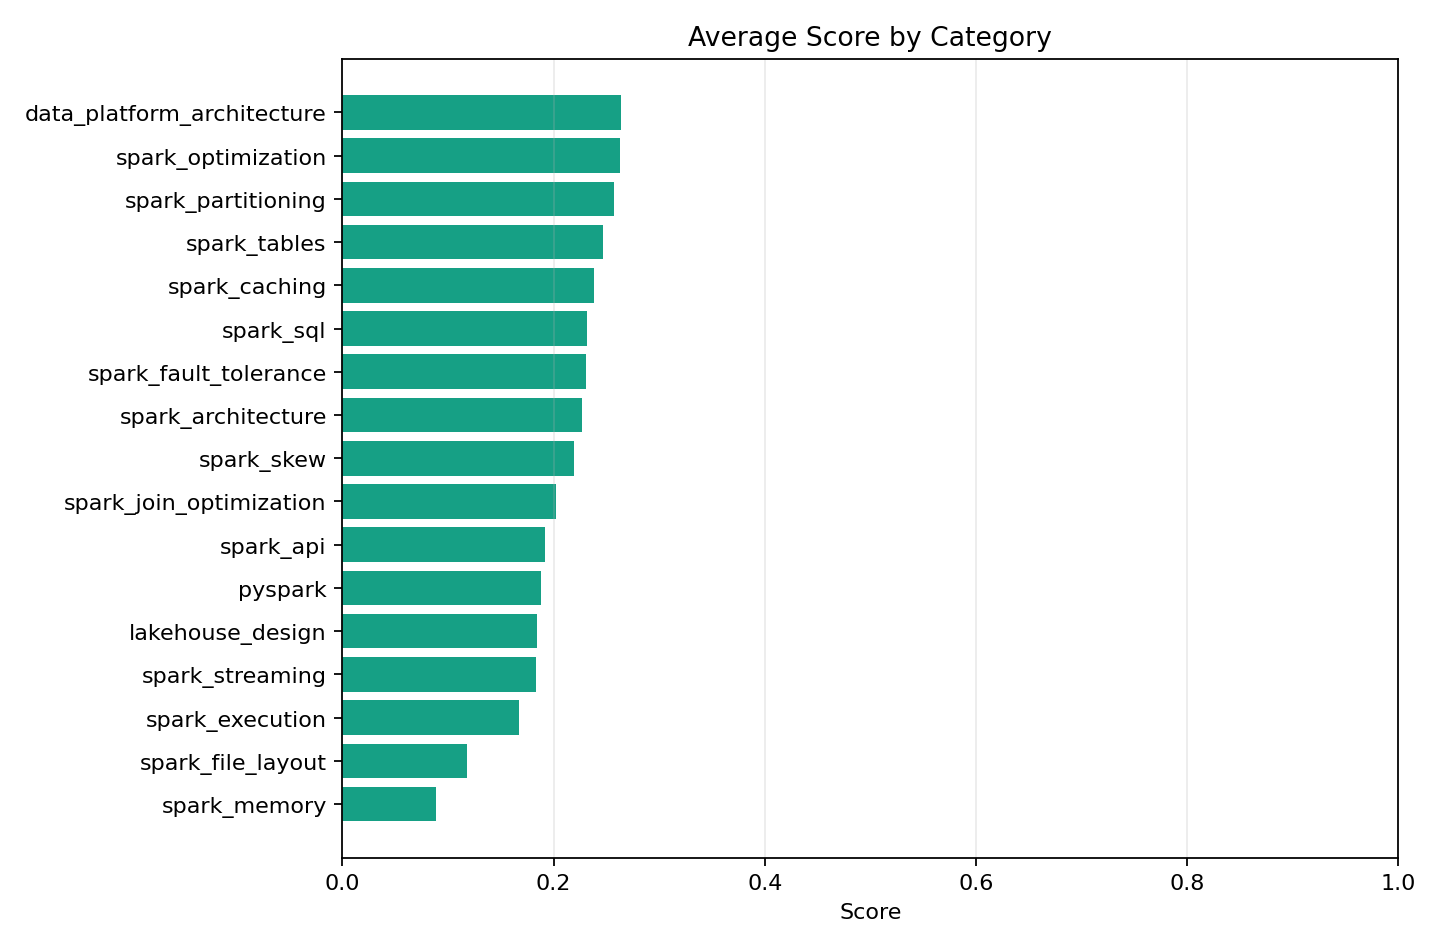

/content/a-triple-of-lms/benchmark_results/latency_by_difficulty.png


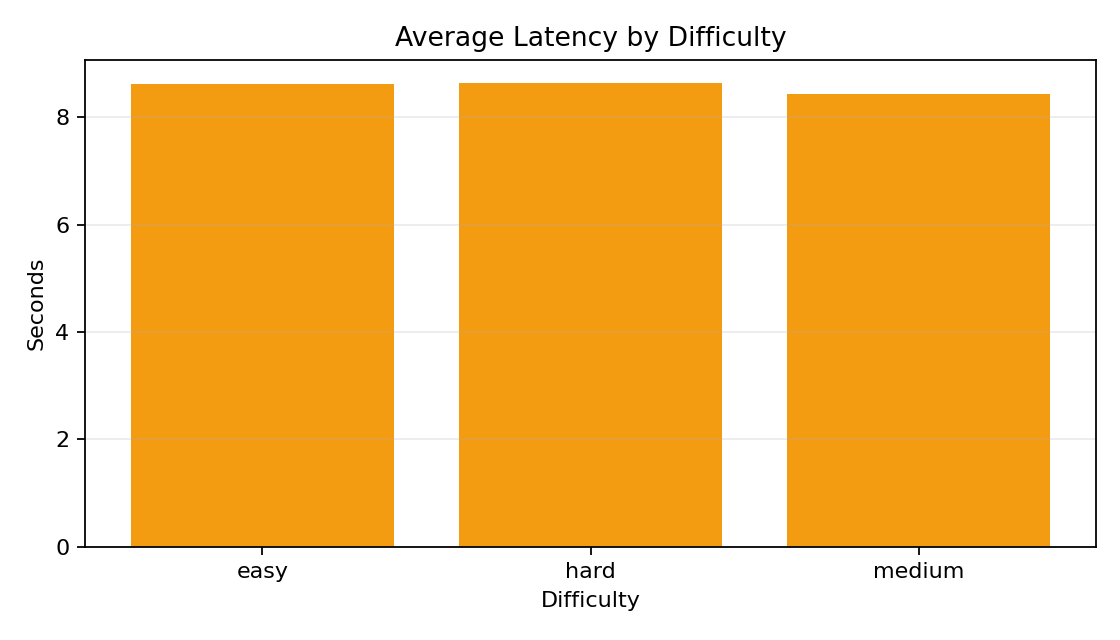

/content/a-triple-of-lms/benchmark_results/score_vs_latency.png


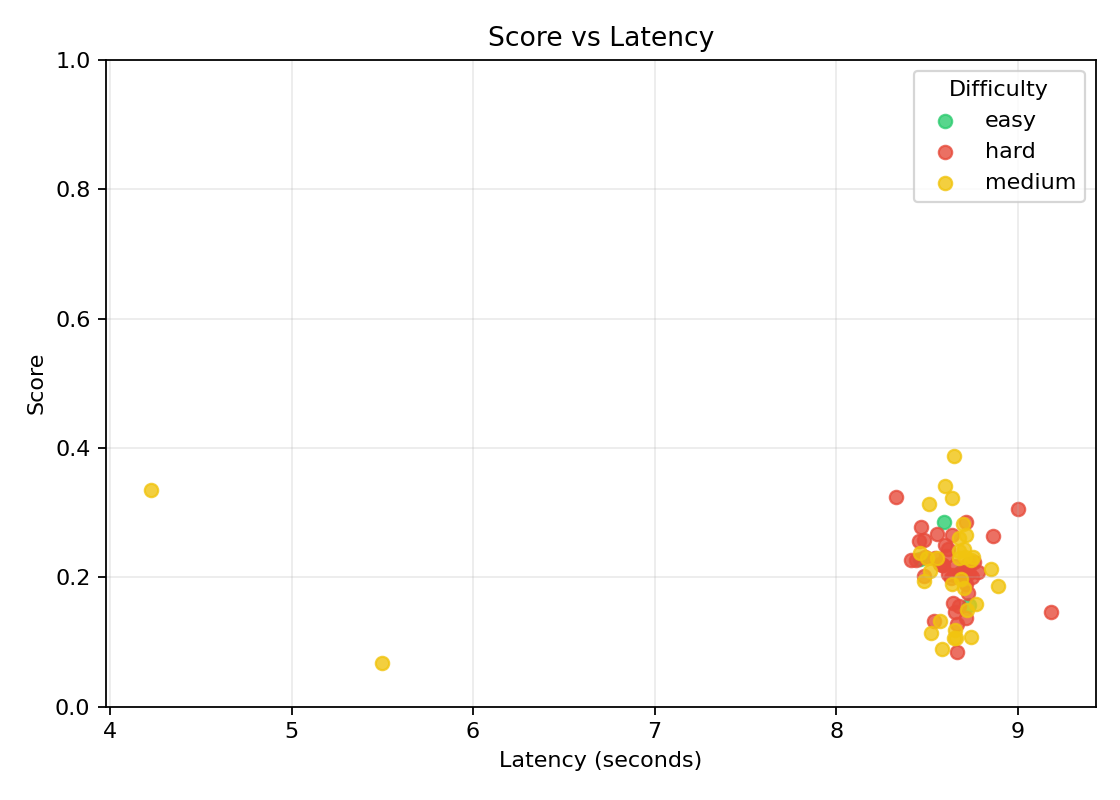

In [41]:
# Hiển thị charts trong notebook.
from IPython.display import Image, display

for chart_path in chart_paths:
    print(chart_path)
    display(Image(filename=str(chart_path)))

In [42]:
# Hiển thị báo cáo các câu có điểm thấp nhất.
from IPython.display import Markdown, display

display(Markdown(low_score_report_path.read_text(encoding="utf-8")))

# Low Score Analysis

Các câu dưới đây có điểm tự động thấp nhất. Nên đọc thủ công để phân biệt lỗi thật của model với hạn chế của metric token/keyword.

## 33. How do you handle data skewness in Spark?

- Category: `spark_join_optimization`
- Difficulty: `medium`
- Auto score: `0.0673`
- Token F1: `0.1132`
- ROUGE-L: `0.0629`
- Keyword coverage: `0.0`

Must-have points:
- Detect skew by inspecting partition sizes, task duration, shuffle read, and hot keys.
- Use salting, skew-aware joins, broadcast joins, pre-aggregation, custom partitioning, and AQE.
- For extreme hot keys, process them separately.
- The right fix depends on whether skew comes from joins, aggregations, file layout, or source partitioning.

Model answer:

To handle data skewness in Spark, I would first identify the skewed keys by analyzing the data distribution. Once identified, I would apply techniques such as salting, which involves adding a random prefix to the keys to distribute the data more evenly across partitions. Another approach is to use custom partitioners that can distribute the data more uniformly. Additionally, I would consider repartitioning the data to ensure a more balanced distribution. It's important to consider the trade-offs, such as increased memory usage and potential impact on performance, when implementing these strategies. In production, I would carefully monitor the system's performance and adjust the strategies as needed to maintain optimal efficiency.

## 22. Design a fault-tolerant Spark Streaming checkpoint strategy: what to persist, recovery semantics, and cost/scalability trade-offs with checkpoint frequency.

- Category: `spark_streaming`
- Difficulty: `hard`
- Auto score: `0.0841`
- Token F1: `0.1065`
- ROUGE-L: `0.0592`
- Keyword coverage: `0.0833`

Must-have points:
- Store checkpoints in durable distributed storage, not local disks.
- Persist offsets, query progress, state store data, and metadata needed to restart consistently.
- Frequent checkpoints improve recovery point objectives but add I/O overhead; infrequent checkpoints are cheaper but increase replay time.
- Pair checkpoints with idempotent sinks or transactional writes to achieve practical exactly-once behavior.

Model answer:

Designing a fault-tolerant Spark Streaming checkpoint strategy involves several considerations to ensure data integrity, minimize recovery time, and balance cost and scalability. Here's a concise strategy:

1. **Persistence Strategy**:
   - **Stateful Operations**: Persist stateful operations (like DStreams) using checkpointing. This ensures that in case of a failure, the state can be recovered.
   - **Non-Stateful Operations**: For non-stateful operations, consider using write-ahead logs (WAL) or other mechanisms like `foreachRDD` to persist data.

2. **Recovery Semantics**:
   - **Checkpointing**: Use checkpointing to save the state of the streaming application at regular intervals. This includes the RDDs, DStreams, and any stateful operations.
   - **Recovery**: In case of failure, Spark Streaming will automatically recover the application state from the checkpointed

## 70. Executors show long GC pauses, frequent full GCs, and occasional OOMs in a SQL workload with joins and aggregations. Which configuration and query changes do you consider first?

- Category: `spark_memory`
- Difficulty: `medium`
- Auto score: `0.0885`
- Token F1: `0.1146`
- ROUGE-L: `0.0625`
- Keyword coverage: `0.0833`

Must-have points:
- Use the SQL and Executors tabs to determine whether pressure comes from shuffle, cache storage, a large broadcast side, UDF object churn, or too much concurrency per executor.
- Query fixes include filtering/projection, changing join strategy, avoiding Python or row-wise UDFs, and removing unnecessary cache.
- Config fixes include moderate executor cores, realistic memory overhead, adjusted shuffle partitions, AQE, and safer broadcast thresholds.

Model answer:

When facing long GC pauses, frequent full GCs, and occasional OOMs in a SQL workload with joins and aggregations, the first steps should involve both configuration tuning and query optimization. Here's a concise approach to addressing these issues:

1. **Memory Configuration Tuning:**
   - **Increase Heap Size:** If the JVM heap size is too small, it can lead to frequent full GCs. Increase the heap size (`-Xms` and `-Xmx` JVM flags) to accommodate the workload. However, be cautious not to set it too high, as it can lead to longer GC pauses.
   - **Tune Garbage Collection (GC):** Choose a GC algorithm that suits your workload. For SQL workloads, consider using the G1GC or ZGC (if available) for better throughput and reduced pause times. Adjust GC-related flags like `-XX:NewRatio`, `-XX:MaxGCPause

## 80. A foreachBatch job writes each micro-batch to Delta and to a low-latency serving store. How do you design batch logic so restarts do not make the sinks diverge?

- Category: `spark_streaming`
- Difficulty: `medium`
- Auto score: `0.1057`
- Token F1: `0.1339`
- ROUGE-L: `0.0893`
- Keyword coverage: `0.0833`

Must-have points:
- Use the foreachBatch batchId as an idempotency key.
- Write each sink with deterministic upsert or transactional semantics, and record completion status per sink and batch.
- If one sink succeeds and the other fails, the retry should safely skip or reapply the successful write without duplicating effects.
- For strict consistency, use a transactional outbox or make one durable sink the source for replaying the other.

Model answer:

To ensure that restarts do not cause divergence between the Delta table and the low-latency serving store, you can implement the following strategies:

1. Use a consistent checkpointing mechanism: Implement a checkpointing mechanism that records the state of the batch processing at regular intervals. This can be done using Spark's built-in checkpointing feature or by implementing a custom checkpointing system. By doing so, you can resume the processing from the last checkpoint in case of a restart, ensuring that the data written to both the Delta table and the serving store remains consistent.

2. Implement idempotent operations: Ensure that the operations performed on the data during the batch processing are idempotent, meaning that applying the same operation multiple times will not change the result beyond the initial application. This will help prevent divergence between the Delta table and the serving store in case of a restart.

3. Use transactional writes: When writing to the Delta table, use transactional writes

## 66. A left join produces 50 times more rows because the right side has many matches per key, then OOMs during shuffle write. What plan changes keep it stable?

- Category: `spark_join_optimization`
- Difficulty: `medium`
- Auto score: `0.1067`
- Token F1: `0.1914`
- ROUGE-L: `0.0861`
- Keyword coverage: `0.0`

Must-have points:
- First decide whether the multiplicative output is required.
- If not, deduplicate, pre-aggregate, filter, or choose one right-side record per key before joining.
- If all matches are required, estimate output cardinality, increase shuffle parallelism, consider broadcast only when safe, enable AQE, and add data quality checks.
- A 50x expansion is often a modeling or quality issue rather than only a resource problem.

Model answer:

To address the issue of a left join producing 50 times more rows due to many matches per key, leading to Out Of Memory (OOM) errors during shuffle write, consider the following plan changes to keep the process stable:

1. **Data Partitioning**: Partition the data on the join key to reduce the number of rows that need to be shuffled. This can be done using Spark's `repartition` or `coalesce` functions.

2. **Data Sampling**: If the dataset is too large, consider sampling the data before performing the join. This can help reduce the number of rows and avoid OOM errors.

3. **Increase Memory Allocation**: Increase the memory allocation for Spark executors and driver nodes to handle the increased data volume. This can be done by adjusting the `--executor-memory` and `--driver-memory` options in the Spark configuration.

4. **Use Broadcast Join**: If one of the datasets is significantly smaller than

## 6. What strategies can you use to handle skewed data in Spark?

- Category: `spark_join_optimization`
- Difficulty: `medium`
- Auto score: `0.1085`
- Token F1: `0.1163`
- ROUGE-L: `0.0581`
- Keyword coverage: `0.1667`

Must-have points:
- First identify skew from task duration, partition sizes, and key frequency.
- Mitigate it with salting hot keys, splitting heavy keys, broadcast joins for small tables, AQE skew join handling, better partitioning, pre-aggregation, and filtering unnecessary data early.
- Validate the fix by checking shuffle size, spill, and task time distribution.

Model answer:

To handle skewed data in Spark, one can employ several strategies:


1. **Salting**: Add random noise to the data to distribute it more evenly.

2. **Partitioning**: Use custom partitioners to distribute data more evenly across the cluster.

3. **Combining RDDs**: Merge small RDDs into larger ones to reduce the overhead of processing many small tasks.

4. **Broadcast Variables**: Use broadcast variables to send large, read-only data to all nodes, reducing the amount of data shuffled across the network.

5. **Data Sampling**: Use sampling to identify and handle skewed keys.

6. **Custom Aggregation Functions**: Implement custom aggregation functions that can handle skewed data more efficiently.


Trade-offs and production considerations:

- **Salting** can introduce noise, which might affect the accuracy of the results.

- **Part

## 36. How would you read data from a web API using PySpark?

- Category: `pyspark`
- Difficulty: `medium`
- Auto score: `0.1138`
- Token F1: `0.1139`
- ROUGE-L: `0.0759`
- Keyword coverage: `0.1667`

Must-have points:
- For small API pulls, call the API outside Spark or in controlled driver-side batches, then parallelize normalized records.
- For large pulls, create partitioned request ranges and use mapPartitions with rate limiting, retries, timeouts, and backoff.
- Store raw responses first, avoid one HTTP call per row, and protect secrets with a managed secret store.

Model answer:

To read data from a web API using PySpark, you can use the `requests` library to fetch the data and then convert it into a format that PySpark can work with, such as a DataFrame. Here's a concise approach:


1. Fetch the data using the `requests` library:

```python

import requests


response = requests.get('https://api.example.com/data')

data = response.json()

```


2. Convert the JSON data into a PySpark DataFrame:

```python

from pyspark.sql import SparkSession

from pyspark.sql.functions import from_json, col


spark = SparkSession.builder.appName("WebAPIData").getOrCreate()


# Assuming the JSON structure is known and can be defined as a schema

schema = "your_schema_here"


# Convert the JSON data into a DataFrame

df =

## 72. A daily ETL writes a partitioned Delta or Parquet table. Reads were fast initially but slow after weeks even with the same compute. What file layout and write behavior changes stabilize performance?

- Category: `spark_file_layout`
- Difficulty: `medium`
- Auto score: `0.1185`
- Token F1: `0.1611`
- ROUGE-L: `0.0948`
- Keyword coverage: `0.0833`

Must-have points:
- This is usually small-file and metadata growth.
- Control output file sizes with coalesce/repartition, optimized writes, max records per file, and periodic compaction such as Delta OPTIMIZE or a Parquet compaction job.
- Revisit partition columns to avoid high-cardinality over-partitioning, consider clustering or Z-ordering for common filters, and monitor file count, average file size, planning time, and input files per query.

Model answer:

To stabilize performance in a scenario where daily ETL writes to a partitioned Delta or Parquet table result in slow reads after weeks, consider the following strategies:

1. **Partitioning Strategy**: Ensure that the partitioning key is chosen based on the query patterns. If the partition key is not aligned with the most common queries, it can lead to performance degradation due to data skew.

2. **Partition Pruning**: Make sure that queries are written to take advantage of partition pruning. This means that the query should filter on the partition key to avoid scanning unnecessary partitions.

3. **File Format**: Parquet is generally more efficient for read-heavy workloads due to its columnar storage and compression features. If performance issues persist, consider switching to a columnar format like Parquet.

4. **Compression**: Use compression to reduce I/O and improve cache utilization. However, be aware that compression can increase CPU usage during reads. Choose a compression code

## 38. Prioritize Spark optimizations by impact and effort. Discuss partitioning strategy, caching policy, join selection, shuffle reduction, and when each becomes a scalability or cost bottleneck.

- Category: `spark_join_optimization`
- Difficulty: `hard`
- Auto score: `0.1279`
- Token F1: `0.1531`
- ROUGE-L: `0.0714`
- Keyword coverage: `0.1667`

Must-have points:
- Highest-impact first: reduce data scanned, fix bad joins, remove avoidable shuffles, and handle skew.
- Next tune partition counts and file layout.
- Cache only reused expensive intermediates that fit memory.
- Broadcast small dimensions and use sort-merge for large joins.
- Each optimization becomes a bottleneck when it increases spill, executor memory pressure, small files, or long-tail tasks.

Model answer:

When optimizing Spark jobs, it's crucial to balance the impact of each optimization against the effort required to implement it. Here's a prioritized list of Spark optimizations, along with considerations for partitioning strategy, caching policy, join selection, shuffle reduction, and their potential bottlenecks:

1. **Partitioning Strategy**: Proper partitioning is fundamental to Spark's performance. It determines how data is distributed across the cluster. The goal is to minimize data shuffling and ensure that data is evenly distributed. Use a hash partitioner for even distribution and avoid skewed partitions by analyzing data characteristics beforehand.

   - **Bottleneck**: Incorrect partitioning can lead to skewed data processing, causing some nodes to do more work than others, leading to bottlenecks.

2. **Caching Policy**: Caching frequently accessed data in memory can significantly reduce the need for disk I/O. However, caching requires memory resources, so it'

## 23. Design an anti-skew strategy for a join on a high-cardinality key with a long-tail distribution (e.g., a few keys hold 80% of rows). Cover salting, split-skew, AQE, and cost/operational trade-offs.

- Category: `spark_join_optimization`
- Difficulty: `hard`
- Auto score: `0.1323`
- Token F1: `0.1451`
- ROUGE-L: `0.0933`
- Keyword coverage: `0.1667`

Must-have points:
- Measure the hot keys first.
- Salt only skewed keys by adding a random bucket on the large side and duplicating matching small-side rows across buckets.
- Use AQE skew join handling when available, and split extreme keys into separate paths if needed.
- The trade-off is extra data expansion, more complex logic, and operational monitoring versus shorter tail tasks.

Model answer:

To design an anti-skew strategy for a join operation on a high-cardinality key with a long-tail distribution, we can consider the following approaches:

1. Salting:
   - Generate a random salt for each key and store it in a separate column.
   - Perform the join operation on the salted keys.
   - Trade-offs:
     - Increased storage requirements for the salt column.
     - Potential performance impact due to the additional join condition.

2. Split-skew:
   - Split the dataset into multiple smaller datasets based on the key's distribution.
   - Perform the join operation on each smaller dataset.
   - Combine the results from all smaller datasets.
   - Trade-offs:
     - Increased storage requirements for multiple smaller datasets.
     - Potential performance impact due to the additional join operations.

3. Approximate Query Evaluation (AQE):
   - Use sampling techniques to estimate the join result.



## Nhận xét kết quả benchmark

Kết quả trong các biểu đồ cần được đọc cùng giá trị `n` trên từng nhóm. Nếu `BENCHMARK_LIMIT = 0`, notebook đang chạy toàn bộ 80 câu và kết quả có tính đại diện tốt hơn. Nếu đổi về `BENCHMARK_LIMIT = 5`, biểu đồ chỉ là smoke test để kiểm tra pipeline.

**Theo độ khó**, biểu đồ cho biết model giữ chất lượng ổn định hay giảm điểm khi chuyển từ `easy` sang `medium` và `hard`. Nếu nhóm nào có `n` quá thấp, không nên kết luận mạnh từ nhóm đó.

**Theo category**, nhóm có điểm thấp là nơi nên đọc thủ công các câu trả lời. Với Spark, các category dễ làm model mất điểm thường là join optimization, skew, streaming state và fault tolerance, vì câu trả lời cần nhiều điều kiện sử dụng và trade-off production.

**Về latency**, thời gian trả lời trung bình khoảng 8 giây/câu trên T4 và khá ổn định giữa `medium` và `hard`. Với demo seminar, mức này chấp nhận được; nếu chạy full 80 câu thì tổng thời gian có thể vào khoảng 10-15 phút tùy độ dài output và tải GPU.

**Score vs latency** chưa cho thấy quan hệ rõ ràng giữa câu trả lời chậm hơn và điểm cao hơn. Một số câu có latency tương tự nhưng điểm khác nhau đáng kể, nghĩa là chất lượng phụ thuộc nhiều vào mức độ khớp ý với reference answer hơn là thời gian sinh.

## Các cải thiện đã thêm vào benchmark

Benchmark hiện tại không chỉ dùng `token_f1`, `rouge_l` và `keyword_coverage` nữa. Dataset đã có thêm `must_have_points`, và script chấm thêm `must_have_point_coverage` để đo model có nhắc đủ các ý chính bắt buộc hay không. Script cũng chấm `instruction_following` để kiểm tra độ dài, mức liên quan đến Spark, việc tránh refusal và việc có nhắc đến trade-off/production consideration.

Script cũng xuất thêm hai artifact phục vụ review thủ công: `human_review_template.csv` và `low_score_analysis.md`. File CSV cho phép chấm theo rubric 1-5 gồm correctness, completeness, trade-off, production relevance và clarity. File markdown liệt kê các câu điểm thấp nhất để phân tích lỗi định tính.

Các điểm nên làm tiếp nếu muốn benchmark nghiêm túc hơn:

1. Review thủ công 10-20 câu điểm thấp bằng `human_review_template.csv`.
2. So sánh nhiều model hoặc nhiều prompt trên cùng dataset, ví dụ Phi-3 vs Qwen hoặc prompt ngắn vs prompt có rubric.
3. Nếu dùng LLM-as-judge, nên dùng một model mạnh hơn model được chấm và giữ rubric cố định để giảm thiên lệch.

Kết luận ngắn: benchmark hiện tại đã đủ tốt để làm baseline tự động và có artifact phục vụ human review. Tuy nhiên, kết luận cuối cùng vẫn nên dựa trên cả điểm tự động lẫn phân tích thủ công các câu điểm thấp.

In [43]:
# Xem nhanh câu điểm cao/thấp nhất để đưa vào slide demo.
ranked = sorted(results, key=lambda row: row["score"])

print("Lowest score:")
print(json.dumps(ranked[0], ensure_ascii=False, indent=2)[:2000])

print("\nHighest score:")
print(json.dumps(ranked[-1], ensure_ascii=False, indent=2)[:2000])

Lowest score:
{
  "id": 33,
  "question": "How do you handle data skewness in Spark?",
  "category": "spark_join_optimization",
  "difficulty": "medium",
  "reference_answer": "Detect skew by inspecting partition sizes, task duration, shuffle read, and hot keys. Use salting, skew-aware joins, broadcast joins, pre-aggregation, custom partitioning, and AQE. For extreme hot keys, process them separately. The right fix depends on whether skew comes from joins, aggregations, file layout, or source partitioning.",
  "must_have_points": [
    "Detect skew by inspecting partition sizes, task duration, shuffle read, and hot keys.",
    "Use salting, skew-aware joins, broadcast joins, pre-aggregation, custom partitioning, and AQE.",
    "For extreme hot keys, process them separately.",
    "The right fix depends on whether skew comes from joins, aggregations, file layout, or source partitioning."
  ],
  "model_answer": "To handle data skewness in Spark, I would first identify the skewed keys by 